## F1 UNDERCUT ANALYSIS
**Aim is to explore data to help develop a methodology for calculating individual circuit undercut strength.**

In [ ]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

fastf1.Cache.enable_cache("/Users/ethan/dev/formation_lap/.cache/fastf1")

I am choosing Miami 2026. Reason: It's a race from the new regs which is going to be most critical for analysis. The race had notable strategy battles and no safety cars to disrupt it. Miami will act as a base. Other interesting tracks include Bahrain(deg heavy), Monaco(undercut is key) and Catalunya(typical benchmark track).

In [ ]:
session = fastf1.get_session(2026, "Miami", "R")
session.load()

I want to isolate some specific battles. It would be easiest to work backwards, isolating battles and then analyising how these battles could have been identified via the data. The key battle in Miami 2026 was Norris and Antonelli, with Norris finishing just 3.2 seconds behind. I will first visualise cleaned lap time data with stint information.

/var/folders/bt/lc3qpn9d4bl1wtl3v319skjm0000gn/T/ipykernel_78407/647615966.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ant["LapTime_s"] = ant["LapTime"].dt.total_seconds()
/var/folders/bt/lc3qpn9d4bl1wtl3v319skjm0000gn/T/ipykernel_78407/647615966.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nor["LapTime_s"] = nor["LapTime"].dt.total_seconds()


Text(0.5, 1.0, 'NORRIS - 2026 Miami GP')

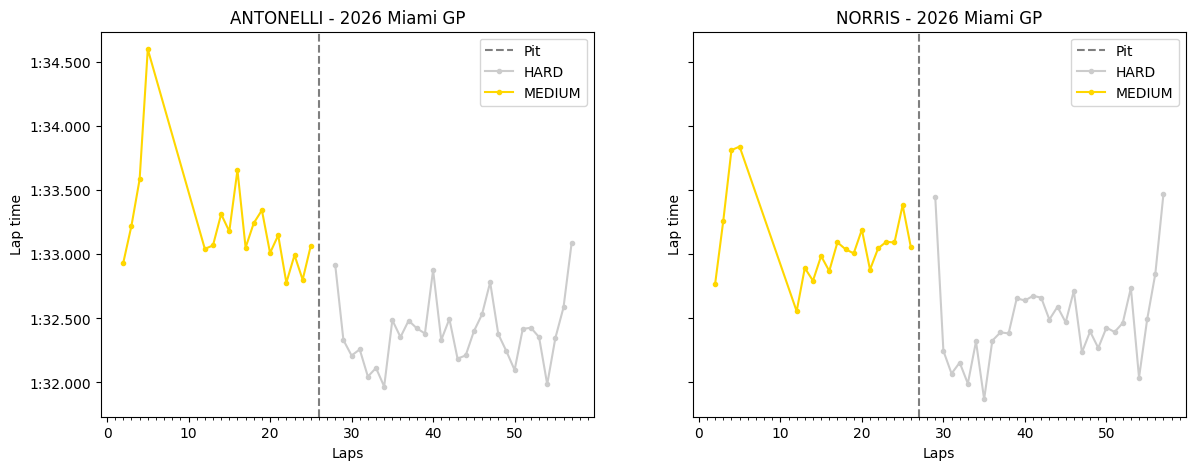

In [ ]:
compounds = {"SOFT": "#FF3333", "MEDIUM": "#FFD700", "HARD": "#CCCCCC"}

ant = session.laps.pick_drivers("ANT")
nor = session.laps.pick_drivers("NOR")

ant["LapTime_s"] = ant["LapTime"].dt.total_seconds()
nor["LapTime_s"] = nor["LapTime"].dt.total_seconds()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5) ,sharey=True)

def lap_plot(d, ax):
    """For later use."""
    pit_laps = d[d["PitInTime"].notna()]["LapNumber"]
    d = d.pick_accurate().copy()
    for lap in pit_laps:
        ax.axvline(x=lap, color="black", linestyle="--", alpha=0.5, label="Pit")

    for compound, group in d.groupby("Compound"):
        ax.plot(
            group["LapNumber"],
            group["LapTime_s"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            color=compounds.get(compound, "pink"),
            label=compound,
        )

    ax.legend()
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{int(x // 60)}:{x % 60:06.3f}")
    )
    ax.set_xlabel("Laps")
    ax.set_ylabel("Lap time")


for d, ax in ((ant, ax1), (nor, ax2)):
    lap_plot(d, ax)

ax1.set_title("ANTONELLI - 2026 Miami GP")
ax2.set_title("NORRIS - 2026 Miami GP")

We can see that Antonelli pits only one lap earlier than Norris. This means we will be looking at a one lap undercut for this race. The fundamental component we need for calculuting undercut strength is how pace compares on old compounds vs fresh compounds. It can be observed that the Hard is faster for almost all of its stint compared to the Medium (likely due to fuel). This is a positive signal; it means **we don't have to consider which compound transition is taking place for our calculation.** 

I will now produce plots looking at tyre pace and degradation.

In [49]:
def get_coeffs(d):
    stints = d.groupby("Stint")

    med_stint = stints.get_group(1).copy()
    med_stint["LapTime_s"] = med_stint["LapTime"].dt.total_seconds()

    # clean
    med_stint = med_stint[
        (med_stint["LapTime_s"].notna())
        & (
            ~med_stint["TrackStatus"].isin(["4", "5", "6", "7"])
        )  # also drops transition laps (e.g '41')
        & (med_stint["TyreLife"] > 1)  # remove out-lap
        & (med_stint["PitInTime"].isna())  # remove in-lap
    ]

    coeffs = np.polyfit(med_stint["TyreLife"], med_stint["LapTime_s"], 1)
    return coeffs


ant_c, nor_c = get_coeffs(ant), get_coeffs(nor)
print(ant_c)
print(nor_c)


[ -0.35765783 100.52302808]
[-0.31293716 99.72419162]


Interesting finding here. Tyre deg is so minimal on the medium compound that lap time decreases lap by lap(-0.36 & -0.31). Probable causes include fuel loss (weight) and track evolution. This number is going to vary a lot at different tracks (and races from the previous regs?) - It is a key factor for our undercut calculation. 

It's worth comparing these numbers with a comparable Miami GP from the previous regs. 

core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 81 completed the race distance 00:00.036000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '23', '12', '16', '44', '55', '22', '6', '31',

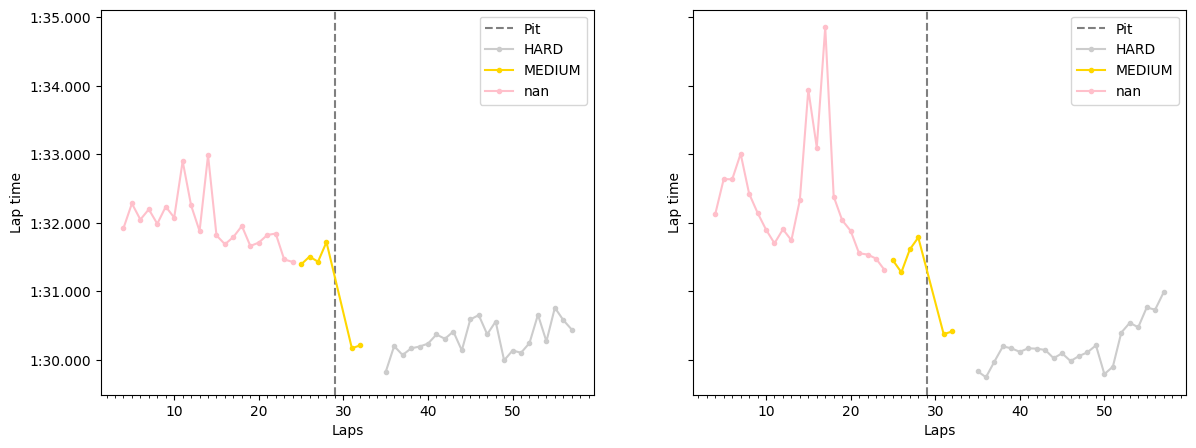

In [55]:
old_session = fastf1.get_session(2025, "miami", "R")
old_session.load()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# top 2 drivers: PIA, NOR
pia = old_session.laps.pick_drivers("PIA")
nor = old_session.laps.pick_drivers("NOR")

pia["LapTime_s"] = pia["LapTime"].dt.total_seconds()
nor["LapTime_s"] = nor["LapTime"].dt.total_seconds()

lap_plot(pia, ax1)
lap_plot(nor, ax2)


NaN values are a known issue in FastF1. We can see from the transition between NaN and Medium that there are no dropped laps for pits and therefore infer the NaN values are infact Medium. We will have to account for this issue occuring in our unsupervised data flows.

With this in mind, the strategy was the same between the races, with pit window ~5 laps later in 2025.

In [56]:
pia_c, nor_c = get_coeffs(pia), get_coeffs(nor)
print(pia_c)
print(nor_c)

[ 0.55825    92.00858333]
[ 0.44428571 91.90407143]


Once again, 